# Advanced Data Visualization using Seaborn

Seaborn is a powerful Python library built on top of Matplotlib. It provides high-level functions for creating informative and attractive statistical plots and integrates closely with pandas data structures..

In [27]:
import seaborn as sns

In [28]:
import matplotlib.pyplot as plt

## Loading builtin dataset

In [29]:
tips_df = sns.load_dataset('tips')

In [30]:
tips_df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [31]:
tips_df.describe(include='all')

,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000


### Visualizing relationship between variables 

c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


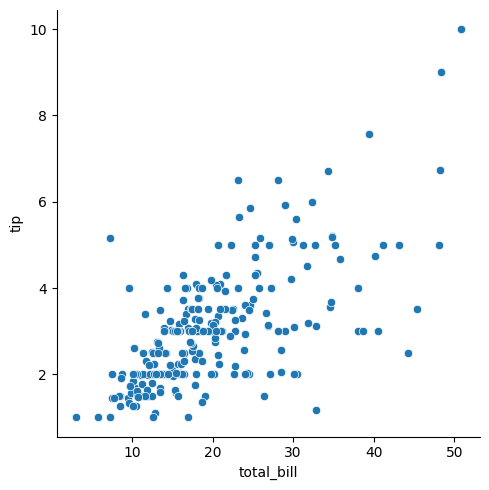

In [32]:
sns.relplot(
    data=tips_df,
    x="total_bill", y="tip")
    #hue="smoker", style="smoker", size="size",
#)

c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


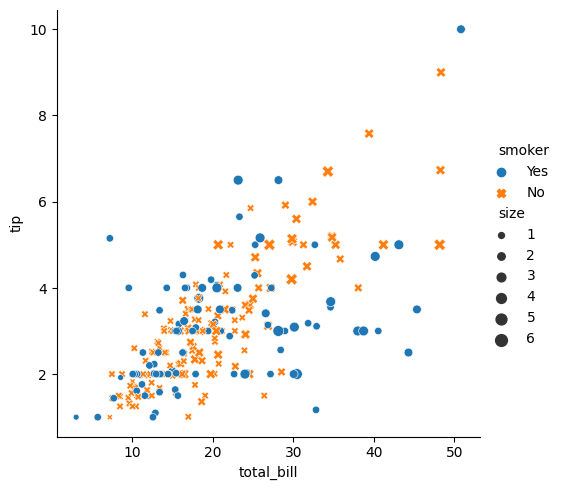

In [34]:
sns.relplot(
    data=tips_df,
    x="total_bill", y="tip",
    hue="smoker",  style="smoker",size="size",
)

---------------------------------------------------------------------------------------
1. Relationship Between Total Bill & Tip (Main Trend)

There is a positive correlation between total_bill and tip.

As the total bill increases, the tip amount also tends to increase.

The points spread upward as we move right on the x-axis.

This is expected because larger bills generally result in larger tips

---------------------------------------------------------------------------------------

2. Party Size (Marker Size Legend)

Marker size represents the number of people at the table.

Observations:

Most points are small, meaning the majority of groups are small (1–3 people).

Larger groups (size 5–6) appear at higher bill amounts, which is logical:

Bigger parties produce higher bills.

Conclusion:
Larger party size generally leads to higher total bills and slightly larger tips, but the relationship isn’t extremely strong.
---------------------------------------------------------------------------------------

c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


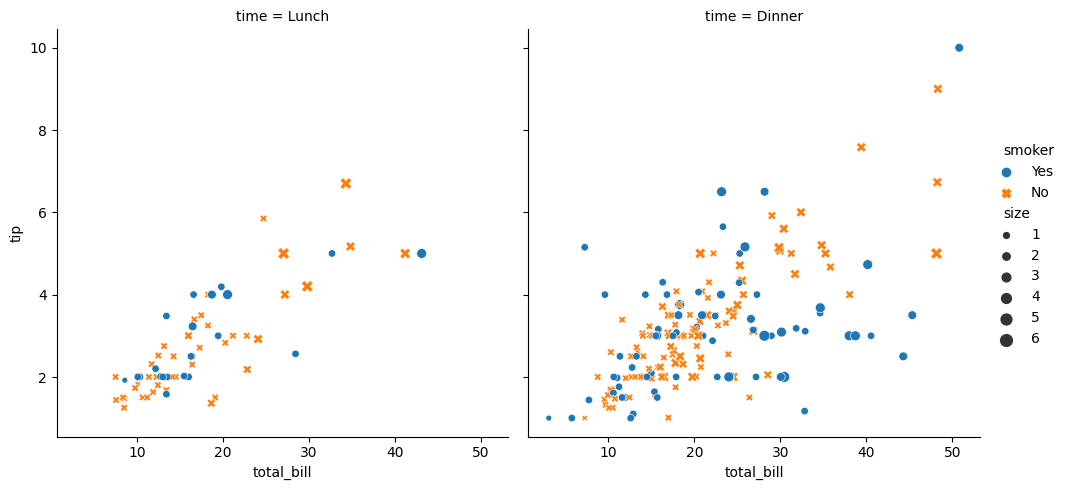

In [22]:
sns.relplot(
    data=tips_df,
    x="total_bill", y="tip", col="time",
    hue="smoker", style="smoker", size="size",
)

### Heatmaps  (Correlation & Matrix Visualization)

A heatmap shows data values as colors. It’s commonly used to visualize correlation between features.

In [35]:
corr = tips_df.corr(numeric_only=True)

In [36]:
corr

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


Correlation values range from -1 to +1:

+1 → perfect positive relationship

0 → no relationship

–1 → perfect negative relationship

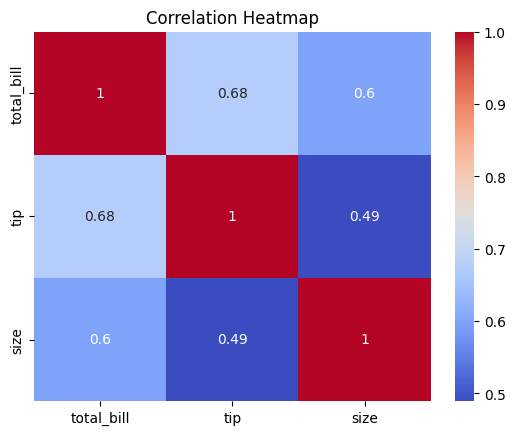

In [37]:
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

| Pair                  | Correlation | Meaning                                            |
| --------------------- | ----------- | -------------------------------------------------- |
| **total_bill ↔ tip**  | **0.68**    | Strong positive; higher bills → higher tips        |
| **total_bill ↔ size** | **0.60**    | Moderately positive; bigger groups spend more      |
| **tip ↔ size**        | **0.49**    | Weak–moderate positive; bigger groups may tip more |


### Pair Plots (Explore pairwise relationships in a dataset)

It is used for visualizing relationship between multiple variable/features in a dataset in a pairwise fashion.

A pairplot creates scatter plots between all numerical columns plus histograms on the diagonals.

c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c

<Figure size 400x500 with 0 Axes>

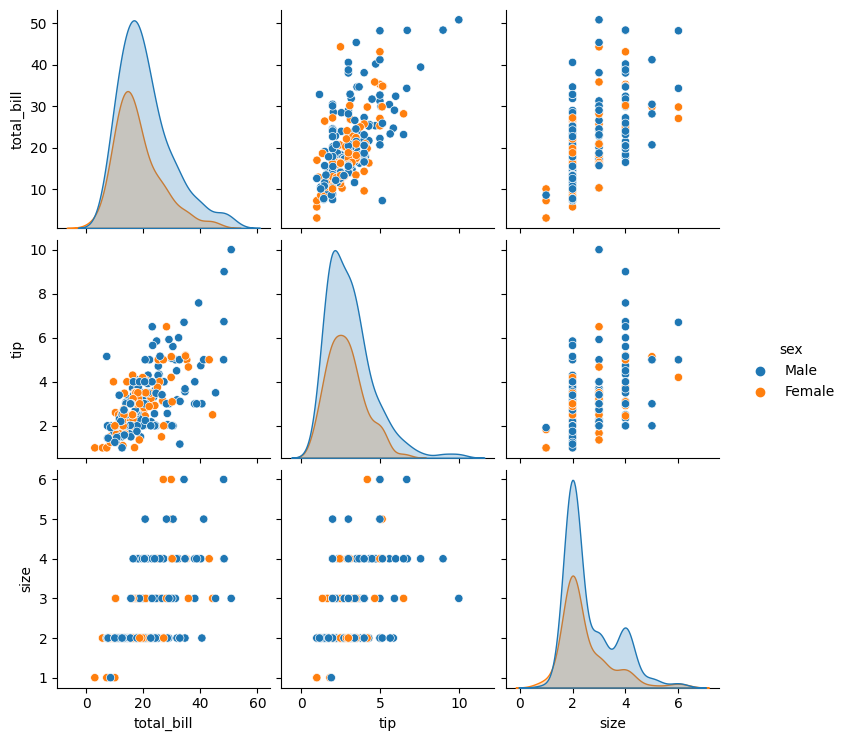

In [25]:
plt.figure(figsize=(4,5))
sns.pairplot(tips_df, hue="sex")
plt.show()

### Interpretation of PairPlot (total_bill, tip, size vs sex)

This pair plot shows pairwise relationships between three numerical variables in the tips dataset:

1. total_bill

2. tip

3. size (number of people)

Colored by sex (Male = blue, Female = orange)

The plot includes scatterplots (relationships between pairs) and KDE curves (distributions).

#### 1. Diagonal Plots: Distribution of Each Variable
a) total_bill Distribution

Both male and female customers show a similar spending pattern.

Most bills fall between 10 and 25 dollars.

Males have slightly higher peaks, meaning males tend to spend a bit more.

b) tip Distribution

Most tips lie between 1 and 4 dollars.

Male customers show a slightly broader spread, meaning more variation.

A few high tips (above 7–8 dollars) appear mostly from males.

c) size Distribution

Most groups are 2–4 people.

Group size patterns are similar for both males and females.

Groups of 1, 5, and 6 people are less common.

#### 2. Scatter Plots: Relationship Between Variables
a) total_bill vs tip

Clear positive relationship: higher bills → higher tips.

Both males and females follow the same trend.

Some males give very high tips on high bills.

b) total_bill vs size

Bigger party size often results in higher total bill.

Males appear slightly more frequent in larger groups.

c) tip vs size

Weak positive relationship:

Larger groups give slightly higher tips, but not strongly.

Many points overlap for both genders → similar tipping pattern.

#### 3. Comparison Between Males and Females
Spending Behavior

Males appear slightly more likely to have higher total bills.

Tipping Behavior

Both genders tip similarly for most bill amounts.

Very high tips (8–10 dollars) appear more frequently for males.

Group Size

Both groups dine in similar-sized parties.

Slightly more male entries in higher group sizes, but difference is small.

### Violin Plots (Distribution + Boxplot Combined)

A violin plot in Seaborn is a powerful visualization tool that displays the distribution of quantitative data across different categories. It combines aspects of a box plot and a kernel density estimate (KDE) plot, providing a more comprehensive view of the data's distribution than a traditional box plot alone.

Shows distribution + density + quartiles in one plot.
Great for comparing categories

In [26]:
tips_df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


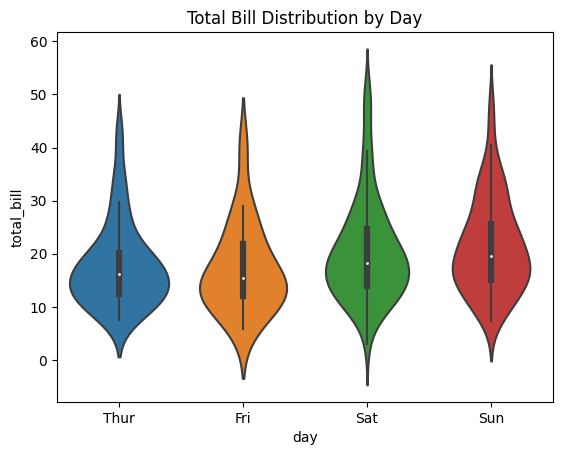

In [20]:
sns.violinplot(x="day", y="total_bill", data=tips_df)
plt.title("Total Bill Distribution by Day")
plt.show()